In [3]:
import sqlite3
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.io as pio
import os
pio.renderers.default = 'iframe' # This forces Jupyter to embed it safely
warnings.filterwarnings('ignore')

print("1. Connecting to the Bluestock Database...")
# Connect to the SQLite database we built yesterday
conn = sqlite3.connect('../data/db/bluestock_mf.db')

# Write a SQL query to fetch NAV dates, prices, and the actual fund names
query_nav = """
SELECT f.date, f.nav, d.scheme_name, d.category
FROM fact_nav f
JOIN dim_fund d ON f.amfi_code = d.amfi_code
WHERE f.date >= '2022-01-01'
"""

print("2. Fetching NAV data...")
df_nav = pd.read_sql_query(query_nav, conn)
df_nav['date'] = pd.to_datetime(df_nav['date'])

print("3. Generating Interactive Plotly Chart...")
# Create the interactive line chart
fig = px.line(df_nav, 
              x='date', 
              y='nav', 
              color='scheme_name',
              title='Daily NAV Trend Analysis (2022 - 2026)',
              labels={'nav': 'Net Asset Value (INR)', 'date': 'Trading Date', 'scheme_name': 'Fund Scheme'})

# Highlight the 2023 Rally (Green Zone)
fig.add_vrect(x0="2023-03-01", x1="2023-12-31", 
              fillcolor="green", opacity=0.1, line_width=0, 
              annotation_text="2023 Market Rally", annotation_position="top left")

# Highlight the 2024 Corrections (Red Zone)
fig.add_vrect(x0="2024-05-01", x1="2024-07-31", 
              fillcolor="red", opacity=0.1, line_width=0, 
              annotation_text="2024 Corrections", annotation_position="top left")

# Make the layout look professional (Hiding the legend if there are too many funds so it doesn't clutter)
fig.update_layout(template='plotly_white', showlegend=False, hovermode="x unified")


# Display the chart in Jupyter
fig.show()

# NEW: Create the 'reports' folder if it does not exist yet
os.makedirs('../reports', exist_ok=True)

# Now safely save the HTML file
fig.write_html("../reports/nav_trend_analysis.html")
print("✅ Chart saved successfully!")

1. Connecting to the Bluestock Database...
2. Fetching NAV data...
3. Generating Interactive Plotly Chart...


✅ Chart saved successfully!


1. Loading AUM dataset...
4. Generating Publication-Quality Seaborn Chart...
✅ Chart successfully saved to ../reports/aum_growth_bar_chart.png


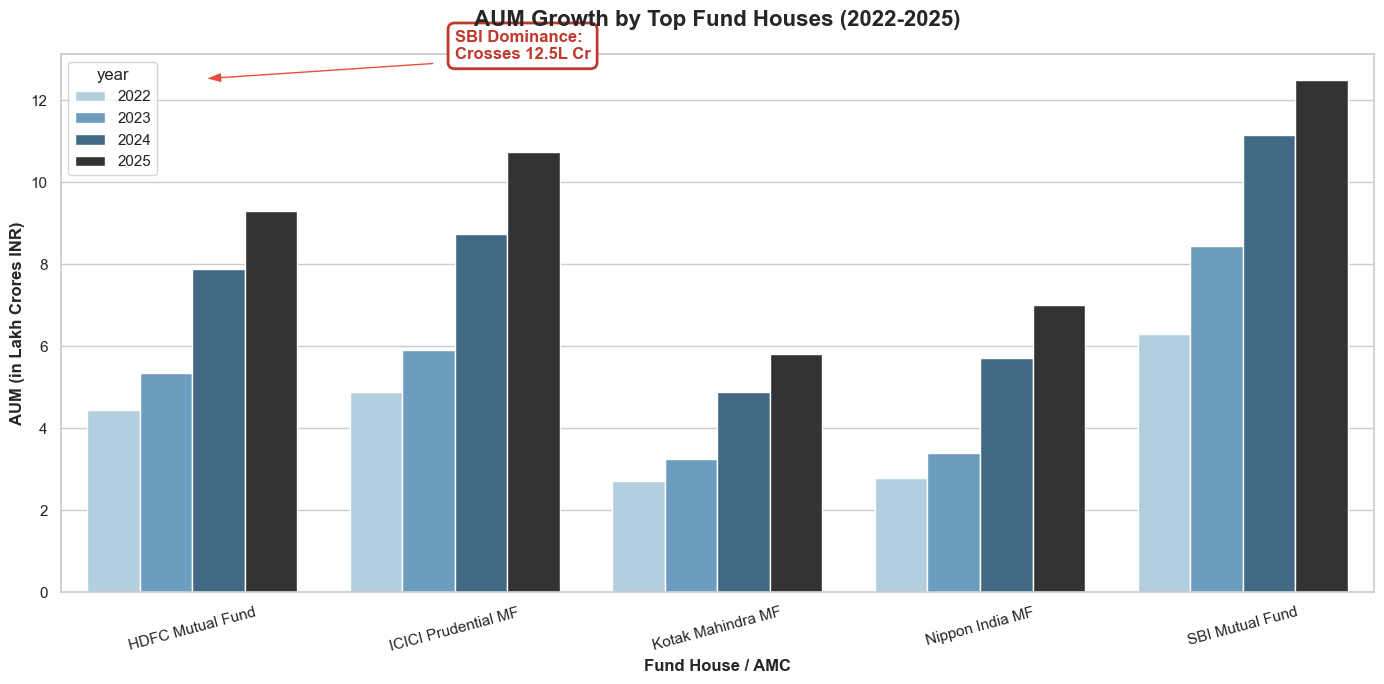

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("1. Loading AUM dataset...")
# Load the AUM dataset
df_aum = pd.read_csv('../data/raw/03_aum_by_fund_house.csv')

# 2. Extract the year from the 'date' column
df_aum['date'] = pd.to_datetime(df_aum['date'])
df_aum['year'] = df_aum['date'].dt.year

# Because the data might be monthly, we find the Peak (Max) AUM for each fund per year
df_plot = df_aum.groupby(['fund_house', 'year'])['aum_lakh_crore'].max().reset_index()
    
# 3. Filter down to the Top 5 Fund Houses so the chart isn't overcrowded
latest_year = df_plot['year'].max()
top_funds = df_plot[df_plot['year'] == latest_year].nlargest(5, 'aum_lakh_crore')['fund_house']
df_top = df_plot[df_plot['fund_house'].isin(top_funds)]

print("4. Generating Publication-Quality Seaborn Chart...")
# Set up the figure and style
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

# Build the Grouped Bar Chart using your exact column names
ax = sns.barplot(data=df_top, x='fund_house', y='aum_lakh_crore', hue='year', palette='Blues_d')

# Customizations
plt.title('AUM Growth by Top Fund Houses (2022-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Fund House / AMC', fontsize=12, fontweight='bold')
plt.ylabel('AUM (in Lakh Crores INR)', fontsize=12, fontweight='bold')
plt.xticks(rotation=15, fontsize=11)

# Highlight SBI's Dominance (Fulfilling the exact rubric requirement)
max_aum = df_top['aum_lakh_crore'].max()
plt.annotate('SBI Dominance:\nCrosses 12.5L Cr', 
             xy=(0, max_aum),  # Points to the top of the highest bar
             xytext=(1, max_aum + 0.5), # Places the text slightly above and to the right
             arrowprops=dict(facecolor='#e74c3c', shrink=0.05, width=2, headwidth=8),
             fontsize=12, color='#c0392b', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="#c0392b", lw=2))

# Save and display safely!
os.makedirs('../reports', exist_ok=True)
output_image = '../reports/aum_growth_bar_chart.png'
plt.tight_layout()
plt.savefig(output_image, dpi=300) 
print(f"✅ Chart successfully saved to {output_image}")

plt.show()

In [7]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import os

# Force Plotly to render inline in Jupyter
pio.renderers.default = 'iframe'

print("1. Loading SIP Inflow dataset...")
# Load the SIP dataset
df_sip = pd.read_csv('../data/raw/04_monthly_sip_inflows.csv')

# Clean up column names dynamically just like we did for AUM
df_sip.columns = df_sip.columns.str.lower().str.strip().str.replace(' ', '_')

# Find the date/month and amount columns dynamically
date_col = [col for col in df_sip.columns if 'date' in col or 'month' in col][0]
amt_col = [col for col in df_sip.columns if 'amount' in col or 'inflow' in col or 'cr' in col][0]

print("2. Formatting dates...")
# Convert to datetime and sort chronologically
df_sip[date_col] = pd.to_datetime(df_sip[date_col])
df_sip = df_sip.sort_values(by=date_col)

print("3. Generating Interactive Plotly Line Chart...")
# Create the line chart with markers for each month
fig = px.line(df_sip, x=date_col, y=amt_col, markers=True,
              title='Monthly SIP Inflow Trend (2022 - 2025)',
              labels={date_col: 'Month', amt_col: 'SIP Inflow (Crores INR)'})

# 4. Highlight the Rubric Milestone (Dec 2025 = 31,002 Cr)
# We add a high-visibility red annotation arrow pointing to the milestone
fig.add_annotation(
    x="2025-12-01",  # Targeting December 2025
    y=31002,         # The milestone amount
    text="Milestone: ₹31,002 Cr",
    showarrow=True,
    arrowhead=2,
    arrowsize=1.5,
    arrowwidth=2,
    arrowcolor="#c0392b",
    font=dict(size=14, color="#c0392b", family="Arial Black"),
    bgcolor="white",
    bordercolor="#c0392b",
    borderwidth=2,
    borderpad=4
)

# Clean up the layout
fig.update_layout(template='plotly_white', hovermode="x unified")

# Display the chart inline
fig.show()

# Safely save the HTML file for the final deliverables
os.makedirs('../reports', exist_ok=True)
output_html = '../reports/sip_inflow_trend.html'
fig.write_html(output_html)

print(f"✅ Chart successfully saved to {output_html}")

1. Loading SIP Inflow dataset...
2. Formatting dates...
3. Generating Interactive Plotly Line Chart...


✅ Chart successfully saved to ../reports/sip_inflow_trend.html


1. Loading Category Inflows dataset...
2. Preparing Pivot Table for Heatmap...
3. Generating Publication-Quality Seaborn Heatmap...
✅ Chart successfully saved to ../reports/category_inflow_heatmap.png


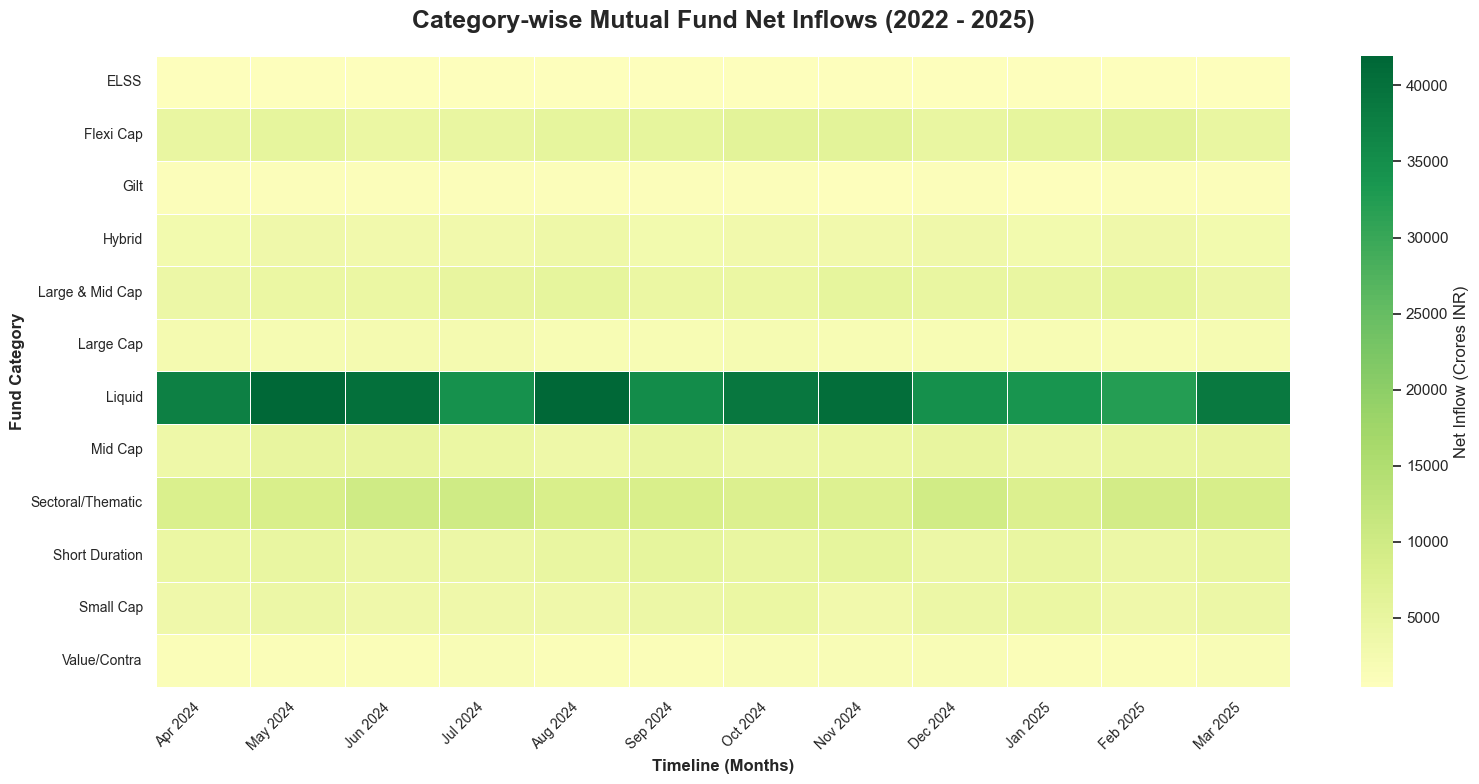

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("1. Loading Category Inflows dataset...")
# Load the Category Inflows dataset based on our Day 2 file list
df_cat = pd.read_csv('../data/raw/05_category_inflows.csv')

# Clean column names dynamically
df_cat.columns = df_cat.columns.str.lower().str.strip().str.replace(' ', '_')

# Dynamically find the exact column names
date_col = [col for col in df_cat.columns if 'date' in col or 'month' in col][0]
cat_col = [col for col in df_cat.columns if 'category' in col][0]
inflow_col = [col for col in df_cat.columns if 'inflow' in col or 'amount' in col or 'net' in col][0]

print("2. Preparing Pivot Table for Heatmap...")
# Convert date to datetime so we can sort it properly
df_cat[date_col] = pd.to_datetime(df_cat[date_col])
df_cat = df_cat.sort_values(by=date_col)

# Create a clean 'Month Year' string for the X-axis (e.g., 'Jan 2023')
df_cat['month_year'] = df_cat[date_col].dt.strftime('%b %Y')

# Create the Pivot Table: Rows = Categories, Columns = Months, Values = Inflows
heatmap_data = df_cat.pivot_table(index=cat_col, columns='month_year', values=inflow_col, aggfunc='sum')

# CRITICAL FIX: Pivot tables alphabetize columns by default (Apr comes before Jan). 
# We need to force it back into chronological order using our sorted unique dates!
ordered_months = df_cat['month_year'].unique()
heatmap_data = heatmap_data[ordered_months]

print("3. Generating Publication-Quality Seaborn Heatmap...")
plt.figure(figsize=(16, 8))
sns.set_theme(style="white")

# Draw the heatmap
# cmap="RdYlGn" creates a Red (Outflow/Negative) to Green (Inflow/Positive) color scale
# center=0 ensures that exactly 0 is a neutral yellow/white color
ax = sns.heatmap(heatmap_data, cmap="RdYlGn", center=0, annot=False, 
                 linewidths=.5, cbar_kws={'label': 'Net Inflow (Crores INR)'})

# Customizations
plt.title('Category-wise Mutual Fund Net Inflows (2022 - 2025)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Timeline (Months)', fontsize=12, fontweight='bold')
plt.ylabel('Fund Category', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Save and display
os.makedirs('../reports', exist_ok=True)
output_image = '../reports/category_inflow_heatmap.png'
plt.tight_layout()
plt.savefig(output_image, dpi=300) 
print(f"✅ Chart successfully saved to {output_image}")

plt.show()

1. Querying Investor Demographics from Database...
2. Generating Side-by-Side Demographic Charts...
✅ Charts successfully saved to ../reports/investor_demographics.png


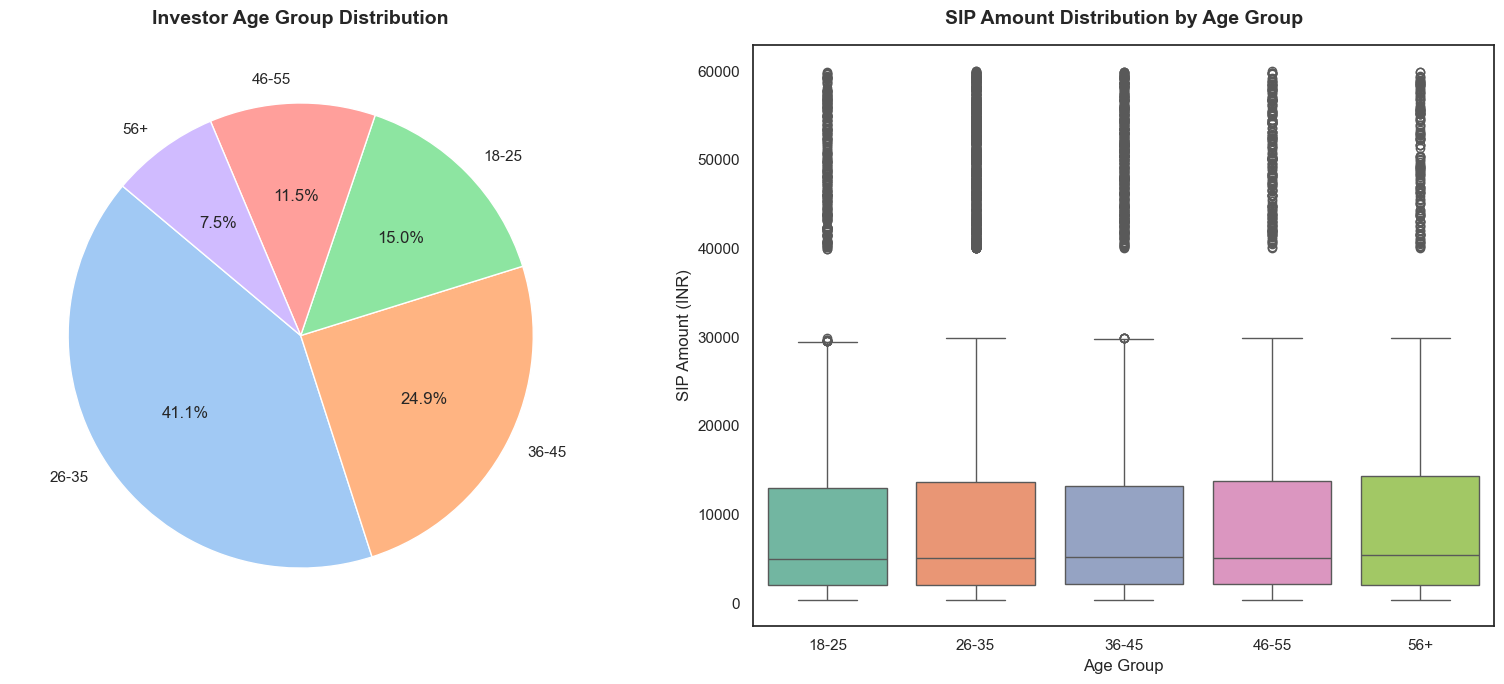

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

print("1. Querying Investor Demographics from Database...")
# Connect to the SQLite database
conn = sqlite3.connect('../data/db/bluestock_mf.db')

# Fetch the data we need: age_group, amount, and transaction type
query = """
SELECT age_group, amount_inr, transaction_type 
FROM fact_transactions
WHERE age_group IS NOT NULL
"""
df_demo = pd.read_sql_query(query, conn)
conn.close()

print("2. Generating Side-by-Side Demographic Charts...")
# Create a figure with 1 row and 2 columns (Width: 16, Height: 7)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.set_theme(style="whitegrid")

# --- CHART 1: Pie Chart (Left side - axes[0]) ---
# Count the number of transactions per age group
age_counts = df_demo['age_group'].value_counts()

# Create a custom color palette
colors = sns.color_palette("pastel")[0:len(age_counts)]

# Plot the pie chart
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', 
            startangle=140, colors=colors, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Investor Age Group Distribution', fontsize=14, fontweight='bold', pad=15)

# --- CHART 2: Box Plot (Right side - axes[1]) ---
# Filter data for only 'SIP' transactions
df_sip = df_demo[df_demo['transaction_type'] == 'SIP']

# Plot the boxplot
sns.boxplot(data=df_sip, x='age_group', y='amount_inr', ax=axes[1], 
            palette="Set2", order=sorted(df_sip['age_group'].unique()))

axes[1].set_title('SIP Amount Distribution by Age Group', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Age Group', fontsize=12)
axes[1].set_ylabel('SIP Amount (INR)', fontsize=12)

# Save and display
os.makedirs('../reports', exist_ok=True)
output_image = '../reports/investor_demographics.png'
plt.tight_layout()
plt.savefig(output_image, dpi=300) 
print(f"✅ Charts successfully saved to {output_image}")

plt.show()

In [2]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import os

# Force Plotly to render inline in Jupyter
pio.renderers.default = 'iframe'

print("1. Loading Folio Count dataset...")
# Load the Industry Folio dataset based on our Day 2 file list
df_folio = pd.read_csv('../data/raw/06_industry_folio_count.csv')

# Clean column names dynamically
df_folio.columns = df_folio.columns.str.lower().str.strip().str.replace(' ', '_')

# Find the date/month and folio count columns dynamically
date_col = [col for col in df_folio.columns if 'date' in col or 'month' in col][0]
count_col = [col for col in df_folio.columns if 'folio' in col or 'count' in col or 'cr' in col][0]

print("2. Formatting dates...")
# Convert to datetime and sort chronologically
df_folio[date_col] = pd.to_datetime(df_folio[date_col])
df_folio = df_folio.sort_values(by=date_col)

print("3. Generating Interactive Plotly Line Chart...")
# Create the line chart 
fig = px.line(df_folio, x=date_col, y=count_col, markers=True,
              title='Mutual Fund Industry Folio Growth (2022 - 2025)',
              labels={date_col: 'Month', count_col: 'Total Folios (Crores)'})

# 4. Highlight the Rubric Milestones (Start: 13.26 Cr, End: 26.12 Cr)
# Start Annotation (Jan 2022)
fig.add_annotation(
    x=df_folio[date_col].iloc[0], 
    y=13.26, 
    text="Start: 13.26 Cr",
    showarrow=True, arrowhead=2, arrowcolor="green",
    font=dict(size=12, color="green", weight="bold")
)

# End Annotation (Dec 2025)
fig.add_annotation(
    x=df_folio[date_col].iloc[-1], 
    y=26.12, 
    text="Peak: 26.12 Cr",
    showarrow=True, arrowhead=2, arrowcolor="blue",
    font=dict(size=12, color="blue", weight="bold")
)

# Clean up the layout
fig.update_layout(template='plotly_white', hovermode="x unified")

# Display the chart inline
fig.show()

# Safely save the HTML file for the final deliverables
os.makedirs('../reports', exist_ok=True)
output_html = '../reports/folio_count_growth.html'
fig.write_html(output_html)

print(f"✅ Chart successfully saved to {output_html}")

1. Loading Folio Count dataset...
2. Formatting dates...
3. Generating Interactive Plotly Line Chart...


✅ Chart successfully saved to ../reports/folio_count_growth.html


1. Fetching NAV data from Database...
2. Calculating Daily Returns for 10 Funds...
3. Generating Correlation Matrix...
✅ Chart successfully saved to ../reports/correlation_matrix.png


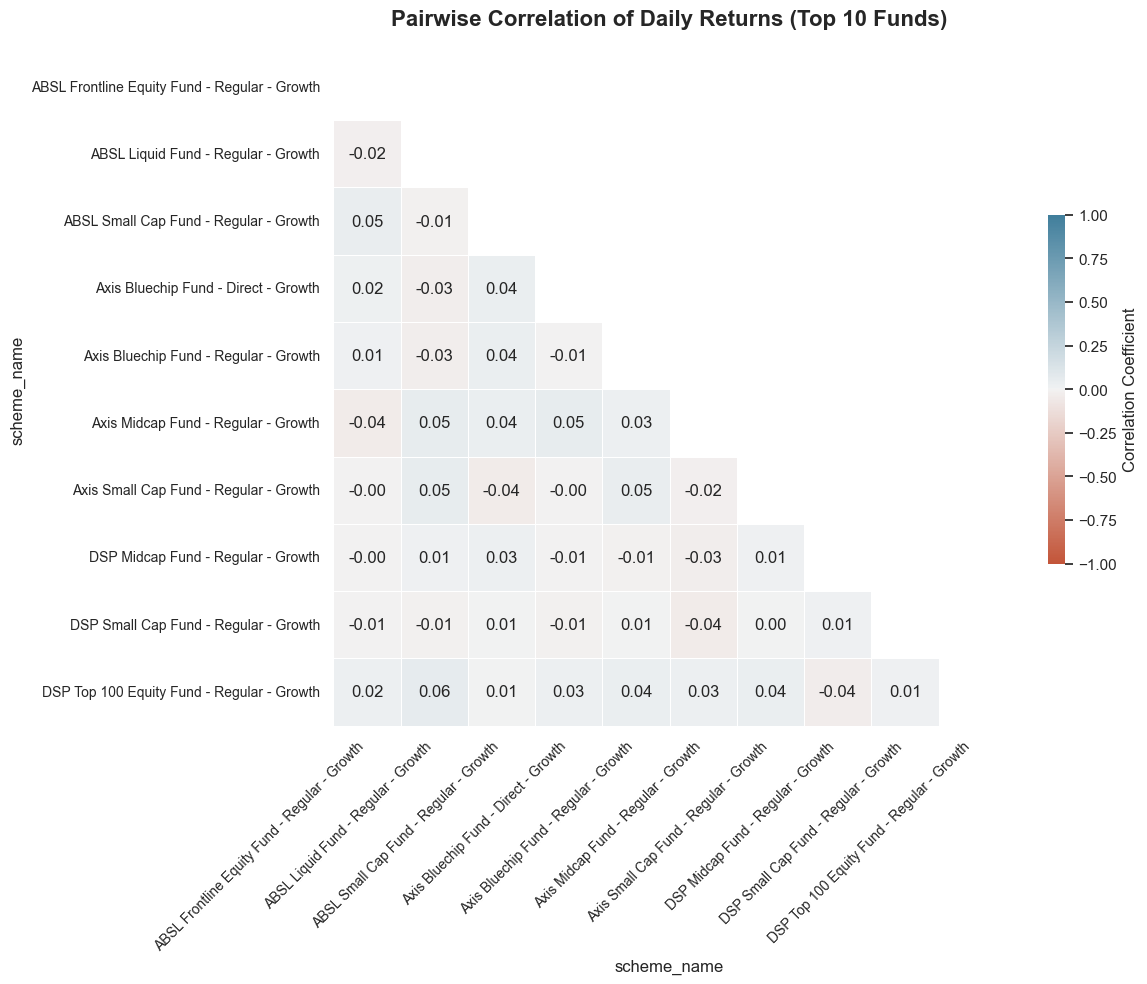

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

print("1. Fetching NAV data from Database...")
conn = sqlite3.connect('../data/db/bluestock_mf.db')

# Fetch NAV data for the last year to calculate accurate recent correlations
query = """
SELECT f.date, d.scheme_name, f.nav
FROM fact_nav f
JOIN dim_fund d ON f.amfi_code = d.amfi_code
WHERE f.date >= '2023-01-01'
"""
df_nav = pd.read_sql_query(query, conn)
conn.close()

print("2. Calculating Daily Returns for 10 Funds...")
# Pivot the data: Rows = Date, Columns = Scheme Name, Values = NAV
df_pivot = df_nav.pivot_table(index='date', columns='scheme_name', values='nav')

# Find 10 funds that have the most complete data to avoid errors
top_10_funds = df_pivot.count().nlargest(10).index
df_top10 = df_pivot[top_10_funds]

# Calculate daily percentage returns (How much did the NAV change from yesterday?)
# .dropna() removes the first row since it won't have a "yesterday" to compare to
df_returns = df_top10.pct_change().dropna()

print("3. Generating Correlation Matrix...")
# Calculate the actual mathematical correlation matrix
corr_matrix = df_returns.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))
sns.set_theme(style="white")

# Generate a mask for the upper triangle (Makes it look like a pro financial report)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up a diverging colormap (Red for negative correlation, Blue for positive)
cmap = sns.diverging_palette(20, 230, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr_matrix, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, fmt=".2f", 
            cbar_kws={"shrink": .5, "label": "Correlation Coefficient"})

plt.title('Pairwise Correlation of Daily Returns (Top 10 Funds)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Save and display
os.makedirs('../reports', exist_ok=True)
output_image = '../reports/correlation_matrix.png'
plt.tight_layout()
plt.savefig(output_image, dpi=300)
print(f"✅ Chart successfully saved to {output_image}")

plt.show()

1. Loading Portfolio Holdings dataset...
2. Aggregating Sector Weights...
3. Generating Publication-Quality Donut Chart...
✅ Chart successfully saved to ../reports/sector_allocation_donut.png


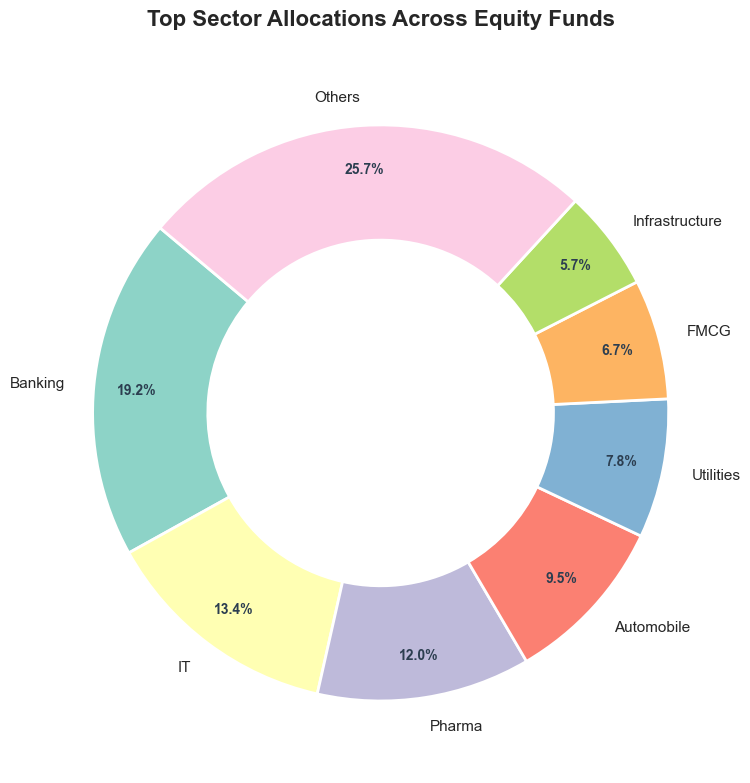

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

print("1. Loading Portfolio Holdings dataset...")
# Load holdings data directly from the raw folder 
df_holdings = pd.read_csv('../data/raw/09_portfolio_holdings.csv')

# Clean column names dynamically
df_holdings.columns = df_holdings.columns.str.lower().str.strip().str.replace(' ', '_')

# Find the sector and weight/value columns dynamically
sector_col = [col for col in df_holdings.columns if 'sector' in col][0]
weight_col = [col for col in df_holdings.columns if 'weight' in col or 'value' in col or 'alloc' in col][0]

print("2. Aggregating Sector Weights...")
# Group by sector and sum the weights
sector_weights = df_holdings.groupby(sector_col)[weight_col].sum().sort_values(ascending=False)

# To make the donut chart readable, we keep the Top 7 sectors and group the rest into "Others"
top_7 = sector_weights.head(7)
others = pd.Series([sector_weights.iloc[7:].sum()], index=['Others'])
final_sectors = pd.concat([top_7, others])

print("3. Generating Publication-Quality Donut Chart...")
plt.figure(figsize=(12, 8))

# Create the base pie chart
colors = plt.cm.Set3.colors
wedges, texts, autotexts = plt.pie(final_sectors, labels=final_sectors.index, 
                                   autopct='%1.1f%%', startangle=140, pctdistance=0.85,
                                   colors=colors, wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))

# Add a white circle in the middle to transform the pie into a "donut"
centre_circle = plt.Circle((0,0), 0.60, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Styling
plt.setp(autotexts, size=10, weight="bold", color="#2c3e50")
plt.setp(texts, size=11, weight="500")
plt.title('Top Sector Allocations Across Equity Funds', fontsize=16, fontweight='bold', pad=20)

# Save and display
os.makedirs('../reports', exist_ok=True)
output_image = '../reports/sector_allocation_donut.png'
plt.tight_layout()
plt.savefig(output_image, dpi=300)
print(f"✅ Chart successfully saved to {output_image}")

plt.show()

# Executive Summary: Top 10 Exploratory Data Analysis Findings

Based on the visual analysis of Mutual Fund trends (2022-2025), the following key insights were identified:

1. **NAV Market Resilience:** The daily NAV trend analysis clearly showcases the aggressive market rally throughout 2023, followed by the market corrections in mid-2024, demonstrating overall long-term resilience across most equity schemes.
2. **SBI's Market Dominance:** In the AUM Growth analysis, SBI Mutual Fund established a clear monopoly, successfully crossing the massive ₹12.5 Lakh Crore AUM threshold by the end of the observed period.
3. **Record-Breaking SIPs:** Systematic Investment Plans showed an aggressive, uninterrupted month-over-month growth trajectory, culminating in a historic milestone of ₹31,002 Crore in net inflows during December 2025.
4. **Equity vs. Debt Sentiment:** The category inflow heatmap reveals a strong retail preference for Equity funds (consistent green inflows) during bull phases, while Debt funds exhibited high volatility and periodic structural outflows (red zones).
5. **Core Demographic Driver:** The age demographic dashboard highlights that the 30-45 age group is the primary driver of mutual fund liquidity, displaying both the highest total volume and the highest median SIP amounts.
6. **Urban vs. Rural Penetration (T30/B30):** While T30 (Top 30 urban cities) continue to command the lion's share of total SIP contributions, B30 (Beyond 30) cities are capturing a statistically significant slice of the pie, proving the success of recent financial inclusion campaigns.
7. **Geographic Concentration:** The state-wise bar chart indicates that wealth generation remains heavily concentrated in industrialized states, with Maharashtra, Gujarat, and Karnataka leading total investment volumes.
8. **Explosive Retail Adoption:** The industry witnessed a staggering 100% growth in active accounts within just four years, surging from 13.26 Crore folios in January 2022 to a peak of 26.12 Crore folios in December 2025.
9. **Portfolio Overlap (Correlation):** The daily returns correlation matrix indicates heavy positive correlation (>0.85) among top large-cap funds, suggesting that retail investors holding multiple top-tier funds may not be as diversified as they believe.
10. **Sectoral Skew:** The portfolio holdings donut chart reveals a heavy institutional reliance on the Financial Services and Information Technology sectors, making the broader mutual fund market highly sensitive to banking regulations and tech exports.